In [1]:
import warnings
warnings.filterwarnings('ignore')

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time

print("\nDOWNLOADING DATASET")

# Dataset URL
DATASET_URL = "https://www.dropbox.com/scl/fi/2jibh9twr8jml97mqtyki/churn_uplift_anonymized.csv?rlkey=907ib1npo2a9zk27ot5ra6zsg&dl=1"

# Create data directory
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
data_path = data_dir / "churn_uplift_anonymized.csv"

# Download dataset
try:
    if not data_path.exists():
        print(f"Downloading dataset from Dropbox...")
        import urllib.request
        urllib.request.urlretrieve(DATASET_URL, data_path)
        print(f"Dataset downloaded to: {data_path}")
    else:
        print(f"Dataset already exists at: {data_path}")
except Exception as e:
    print(f"Could not download automatically: {e}")
    print("\nPlease download manually:")
    print(f"1. Visit: {DATASET_URL}")
    print(f"2. Save as: {data_path}")
    print("\nThen run the script again.")
    # Don't raise - allow manual download


DOWNLOADING DATASET
Dataset already exists at: data/churn_uplift_anonymized.csv


In [2]:
# Standard libraries
from scipy import stats

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression           # propensity model
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, auc
)
from sklearn.ensemble import RandomForestClassifier

# Gradient Boosting
from xgboost import XGBClassifier, XGBRegressor               # XGBRegressor for X-Learner
from lightgbm import LGBMClassifier

# Uplift Modeling (Uber's CausalML)
from causalml.inference.meta import (
    BaseTClassifier, BaseSClassifier,
    BaseXClassifier                                            # X-Learner
)
from causalml.metrics import auuc_score, qini_score

# Explainability
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print('All libraries imported successfully')

# =============================================================================
# SECTION 2: LOAD AND INSPECT DATASET
# =============================================================================
print('\n' + '=' * 80)
print('SECTION 2: DATASET INSPECTION')
print('=' * 80)

df = pd.read_csv(data_path)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

pc_cols     = [col for col in df.columns if col.startswith('PC')]
factor_cols = [col for col in df.columns if col.startswith('FACTOR')]
print(f'\nTreatment rate : {df["t"].mean():.2%}')
print(f'Churn rate     : {df["y"].mean():.2%}')
print(f'PC features    : {len(pc_cols)}   FACTOR features: {len(factor_cols)}')

missing = df.isnull().sum().sum()
print(' No missing values' if missing == 0 else f' Found {missing} missing values')

# -- Uplift data health check ------------------------------------------------
print('\n[2.5] UPLIFT DATA HEALTH CHECK')
print('-' * 50)
_ctrl_r = df.loc[df['t']==0, 'y'].mean()
_trt_r  = df.loc[df['t']==1, 'y'].mean()
_ate    = _trt_r - _ctrl_r
print(f'  Treatment rate (ideal ~50%) : {df["t"].mean():.1%}  <- IMBALANCED')
print(f'  Positive outcome rate       : {df["y"].mean():.2%}  <- SPARSE')
print(f'  Control response rate       : {_ctrl_r:.3%}')
print(f'  Treated response rate       : {_trt_r:.3%}')
print(f'  Raw ATE (trt - ctrl)        : {_ate:+.4f}  <- NEAR ZERO')
print()
print('  Fixes applied downstream:')
print('   [1] 4-group stratified split (y x t)')
print('   [2] Propensity-score IPW     (treatment imbalance)')
print('   [3] Within-arm oversampling  (sparse outcome signal)')
print('   [4] X-Learner                (near-zero ATE / unequal arms)')
print('   [5] UpliftRF on TRAIN set    (data-leakage bug fixed)')


All libraries imported successfully

SECTION 2: DATASET INSPECTION
Shape: 11,896 rows x 180 columns

Treatment rate : 75.74%
Churn rate     : 3.43%
PC features    : 160   FACTOR features: 18
 No missing values

[2.5] UPLIFT DATA HEALTH CHECK
--------------------------------------------------
  Treatment rate (ideal ~50%) : 75.7%  <- IMBALANCED
  Positive outcome rate       : 3.43%  <- SPARSE
  Control response rate       : 3.638%
  Treated response rate       : 3.363%
  Raw ATE (trt - ctrl)        : -0.0028  <- NEAR ZERO

  Fixes applied downstream:
   [1] 4-group stratified split (y x t)
   [2] Propensity-score IPW     (treatment imbalance)
   [3] Within-arm oversampling  (sparse outcome signal)
   [4] X-Learner                (near-zero ATE / unequal arms)
   [5] UpliftRF on TRAIN set    (data-leakage bug fixed)


In [3]:

print("SECTION 3: DATA PREPROCESSING")

print("[3.1] ENCODING CATEGORICAL FEATURES")

# Create a copy for processing
df_processed = df.copy()

# Encode FACTOR columns
label_encoders = {}

for col in factor_cols:
    print(f"Encoding {col}... ", end='')
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le
    print(f" ({len(le.classes_)} categories)")

print(f"\n Encoded {len(factor_cols)} categorical features")

# Verify all features are now numeric
print("\n[3.2] VERIFYING DATA TYPES")
print("-" * 40)

feature_cols = [col for col in df_processed.columns if col not in ['t', 'y']]
non_numeric = df_processed[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()

if non_numeric:
    print(f" Still have non-numeric columns: {non_numeric}")
else:
    print(f" All {len(feature_cols)} features are now numeric")

# Prepare arrays
print("\n[3.3] PREPARING DATA ARRAYS")
print("-" * 40)

X = df_processed[feature_cols].values
y = df_processed['y'].values
treatment = df_processed['t'].values

print(f"Feature matrix (X): {X.shape}")
print(f"Outcome vector (y): {y.shape}")
print(f"Treatment vector:   {treatment.shape}")

# Check for any NaN or Inf values
print("\n[3.4] DATA QUALITY CHECK")
print("-" * 40)

nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()

if nan_count > 0:
    print(f"  Found {nan_count} NaN values")
    # Fill NaN with column median
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X = imputer.fit_transform(X)
    print(f" NaN values imputed with median")
else:
    print(f" No NaN values")

if inf_count > 0:
    print(f"  Found {inf_count} Inf values")
    X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10)
    print(f" Inf values replaced")
else:
    print(f" No Inf values")

SECTION 3: DATA PREPROCESSING
[3.1] ENCODING CATEGORICAL FEATURES
Encoding FACTOR1...  (18 categories)
Encoding FACTOR2...  (12 categories)
Encoding FACTOR3...  (1 categories)
Encoding FACTOR4...  (20 categories)
Encoding FACTOR5...  (4 categories)
Encoding FACTOR6...  (20 categories)
Encoding FACTOR7...  (3 categories)
Encoding FACTOR8...  (2 categories)
Encoding FACTOR9...  (4 categories)
Encoding FACTOR10...  (4 categories)
Encoding FACTOR11...  (3 categories)
Encoding FACTOR12...  (3 categories)
Encoding FACTOR13...  (12 categories)
Encoding FACTOR14...  (20 categories)
Encoding FACTOR15...  (20 categories)
Encoding FACTOR16...  (17 categories)
Encoding FACTOR17...  (6 categories)
Encoding FACTOR18...  (7 categories)

 Encoded 18 categorical features

[3.2] VERIFYING DATA TYPES
----------------------------------------
 All 178 features are now numeric

[3.3] PREPARING DATA ARRAYS
----------------------------------------
Feature matrix (X): (11896, 178)
Outcome vector (y): (11896,)


In [4]:
print('SECTION 4: TRAIN-VALIDATION-TEST SPLIT WITH END-TO-END FIXES')
print('=' * 70)

# ---------------------------------------------------------------------------
# FIX 1: 4-GROUP STRATIFICATION  (y x t)
# Stratify on (y, t) jointly so every split keeps rare treated-responders.
# ---------------------------------------------------------------------------
strat_label = y * 2 + treatment          # 4 groups: 0,1,2,3

X_temp, X_test, y_temp, y_test, t_temp, t_test = train_test_split(
    X, y, treatment,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=strat_label
)
strat_temp = y_temp * 2 + t_temp

X_train, X_val, y_train, y_val, t_train, t_val = train_test_split(
    X_temp, y_temp, t_temp,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=strat_temp
)

print(f'Training set   : {X_train.shape[0]:>6,} samples ({X_train.shape[0]/len(X):.1%})')
print(f'Validation set : {X_val.shape[0]:>6,} samples ({X_val.shape[0]/len(X):.1%})')
print(f'Test set       : {X_test.shape[0]:>6,} samples ({X_test.shape[0]/len(X):.1%})')

for nm, ys, ts in [('Train', y_train, t_train),
                   ('Val',   y_val,   t_val),
                   ('Test',  y_test,  t_test)]:
    print(f'  {nm}: outcome={ys.mean():.2%}  treatment={ts.mean():.2%}  '
          f'ctrl_resp={ys[ts==0].mean():.2%}  trt_resp={ys[ts==1].mean():.2%}')

# Feature scaling
print('\n[4.1] FEATURE SCALING')
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
print(' Features standardised (mean=0, std=1)')

# ---------------------------------------------------------------------------
# FIX 2: PROPENSITY SCORE ESTIMATION
# Logistic regression trained ONLY on train set (no leakage).
# Clipped to [0.05, 0.95] to avoid extreme IPW weights.
# ---------------------------------------------------------------------------
print('\n[4.2] PROPENSITY SCORE ESTIMATION')
print('-' * 50)

prop_model = LogisticRegression(
    max_iter=1000, C=1.0, random_state=RANDOM_STATE, n_jobs=-1
)
prop_model.fit(X_train_scaled, t_train)

def clip_prop(p, lo=0.05, hi=0.95):
    return np.clip(p, lo, hi)

propensity_train = clip_prop(prop_model.predict_proba(X_train_scaled)[:, 1])
propensity_val   = clip_prop(prop_model.predict_proba(X_val_scaled)[:, 1])
propensity_test  = clip_prop(prop_model.predict_proba(X_test_scaled)[:, 1])

print(f'  Train: min={propensity_train.min():.3f}  mean={propensity_train.mean():.3f}  max={propensity_train.max():.3f}')
print(f'  Val  : min={propensity_val.min():.3f}  mean={propensity_val.mean():.3f}  max={propensity_val.max():.3f}')

# IPW weights (normalised to mean=1)
ipw_train = np.where(
    t_train == 1,
    1.0 / propensity_train,
    1.0 / (1.0 - propensity_train)
)
ipw_train = ipw_train / ipw_train.mean()

ate_naive = y_train[t_train==1].mean() - y_train[t_train==0].mean()
ate_ipw   = (np.average(y_train[t_train==1], weights=ipw_train[t_train==1]) -
             np.average(y_train[t_train==0], weights=ipw_train[t_train==0]))
ess_ctrl  = ipw_train[t_train==0].sum()**2 / (ipw_train[t_train==0]**2).sum()
ess_trt   = ipw_train[t_train==1].sum()**2 / (ipw_train[t_train==1]**2).sum()

print(f'\n  Naive ATE        : {ate_naive:+.4f}')
print(f'  IPW-adjusted ATE : {ate_ipw:+.4f}')
print(f'  IPW weights      : min={ipw_train.min():.2f}  mean=1.00  max={ipw_train.max():.2f}')
print(f'  Effective N      : control={ess_ctrl:.0f}  treated={ess_trt:.0f}  '
      f'(ratio {ess_trt/ess_ctrl:.2f}x, was {t_train.mean()/(1-t_train.mean()):.2f}x)')

# ---------------------------------------------------------------------------
# FIX 3: WITHIN-ARM OVERSAMPLING  (3.4% positive -> ~15% per arm)
# Oversample y=1 independently inside control and treated arms.
# This prevents positive-rate leakage between arms.
# ---------------------------------------------------------------------------
print('\n[4.3] WITHIN-ARM OVERSAMPLING')
print('-' * 50)

def oversample_arm(X_arm, y_arm, t_arm, target_pos_rate=0.15, rstate=42):
    pos_idx = np.where(y_arm == 1)[0]
    neg_idx = np.where(y_arm == 0)[0]
    if len(pos_idx) < 2:
        return X_arm, y_arm, t_arm
    n_neg      = len(neg_idx)
    n_pos_need = max(int(n_neg * target_pos_rate / (1.0 - target_pos_rate)),
                     len(pos_idx))
    rng        = np.random.RandomState(rstate)
    pos_rs     = rng.choice(pos_idx, size=n_pos_need, replace=True)
    all_idx    = np.concatenate([neg_idx, pos_rs])
    rng.shuffle(all_idx)
    return X_arm[all_idx], y_arm[all_idx], t_arm[all_idx]

ctrl_mask = t_train == 0
trt_mask  = t_train == 1

X_ctrl_os, y_ctrl_os, t_ctrl_os = oversample_arm(
    X_train_scaled[ctrl_mask], y_train[ctrl_mask], t_train[ctrl_mask])
X_trt_os,  y_trt_os,  t_trt_os  = oversample_arm(
    X_train_scaled[trt_mask],  y_train[trt_mask],  t_train[trt_mask])

print(f'  Control arm : {ctrl_mask.sum():,} -> {len(X_ctrl_os):,} samples '
      f'| positive {y_ctrl_os.mean():.1%} (was {y_train[ctrl_mask].mean():.1%})')
print(f'  Treated arm : {trt_mask.sum():,} -> {len(X_trt_os):,} samples '
      f'| positive {y_trt_os.mean():.1%} (was {y_train[trt_mask].mean():.1%})')

# Merge and shuffle
X_train_os = np.vstack([X_ctrl_os, X_trt_os])
y_train_os = np.hstack([y_ctrl_os, y_trt_os])
t_train_os = np.hstack([t_ctrl_os, t_trt_os])

rng  = np.random.RandomState(RANDOM_STATE)
shuf = rng.permutation(len(X_train_os))
X_train_os, y_train_os, t_train_os = (
    X_train_os[shuf], y_train_os[shuf], t_train_os[shuf])

print(f'\n  Merged oversampled set : {len(X_train_os):,} samples')
print(f'  Positive rate          : {y_train_os.mean():.1%}  (was {y_train.mean():.1%})')
print(f'  Treatment rate         : {t_train_os.mean():.1%}')

# Propensity scores for oversampled rows (same fitted model)
prop_os = clip_prop(prop_model.predict_proba(X_train_os)[:, 1])
ipw_os  = np.where(t_train_os==1, 1.0/prop_os, 1.0/(1.0-prop_os))
ipw_os  = ipw_os / ipw_os.mean()
print(f'  IPW (oversampled)      : min={ipw_os.min():.2f}  mean=1.00  max={ipw_os.max():.2f}')


SECTION 4: TRAIN-VALIDATION-TEST SPLIT WITH END-TO-END FIXES
Training set   :  7,137 samples (60.0%)
Validation set :  2,379 samples (20.0%)
Test set       :  2,380 samples (20.0%)
  Train: outcome=3.42%  treatment=75.73%  ctrl_resp=3.64%  trt_resp=3.35%
  Val: outcome=3.45%  treatment=75.75%  ctrl_resp=3.64%  trt_resp=3.39%
  Test: outcome=3.45%  treatment=75.76%  ctrl_resp=3.64%  trt_resp=3.38%

[4.1] FEATURE SCALING
 Features standardised (mean=0, std=1)

[4.2] PROPENSITY SCORE ESTIMATION
--------------------------------------------------
  Train: min=0.050  mean=0.757  max=0.950
  Val  : min=0.050  mean=0.750  max=0.950

  Naive ATE        : -0.0029
  IPW-adjusted ATE : +0.0014
  IPW weights      : min=0.53  mean=1.00  max=10.08
  Effective N      : control=1280  treated=5209  (ratio 4.07x, was 3.12x)

[4.3] WITHIN-ARM OVERSAMPLING
--------------------------------------------------
  Control arm : 1,732 -> 1,963 samples | positive 15.0% (was 3.6%)
  Treated arm : 5,405 -> 6,145 sam

In [5]:

print("SECTION 5: CHURN PREDICTION MODELS")

results = {}

# Class imbalance ratio for XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"\nClass imbalance — neg: {neg_count:,}  pos: {pos_count:,}  ratio: {scale_pos_weight:.1f}x")
print("Using class_weight='balanced' (RF/LGB) and scale_pos_weight (XGB).\n")

from sklearn.metrics import precision_recall_curve

def optimal_threshold_f1(y_true, y_proba):
    """Return threshold that maximises F1 on the given set."""
    prec, rec, thr = precision_recall_curve(y_true, y_proba)
    f1 = 2 * prec * rec / (prec + rec + 1e-10)
    return float(thr[f1.argmax()])

# ── 5.1 Random Forest ──
print("[5.1] RANDOM FOREST (BASELINE)")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
print("Training Random Forest...")
rf_model.fit(X_train_scaled, y_train)

rf_pred_proba = rf_model.predict_proba(X_val_scaled)[:, 1]
rf_thresh     = optimal_threshold_f1(y_val, rf_pred_proba)
rf_pred       = (rf_pred_proba >= rf_thresh).astype(int)

results['RandomForest'] = {
    'AUC':       roc_auc_score(y_val, rf_pred_proba),
    'F1':        f1_score(y_val, rf_pred, zero_division=0),
    'Precision': precision_score(y_val, rf_pred, zero_division=0),
    'Recall':    recall_score(y_val, rf_pred, zero_division=0)
}
print(f"  Optimal threshold: {rf_thresh:.4f}")
for metric, value in results['RandomForest'].items():
    print(f"  {metric:10s}: {value:.4f}")

# ── 5.2 XGBoost ───
print("\n[5.2] XGBOOST (PRIMARY MODEL)")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
print("Training XGBoost...")
xgb_model.fit(X_train_scaled, y_train,
              eval_set=[(X_val_scaled, y_val)], verbose=False)

xgb_pred_proba = xgb_model.predict_proba(X_val_scaled)[:, 1]
xgb_thresh     = optimal_threshold_f1(y_val, xgb_pred_proba)
xgb_pred       = (xgb_pred_proba >= xgb_thresh).astype(int)

results['XGBoost'] = {
    'AUC':       roc_auc_score(y_val, xgb_pred_proba),
    'F1':        f1_score(y_val, xgb_pred, zero_division=0),
    'Precision': precision_score(y_val, xgb_pred, zero_division=0),
    'Recall':    recall_score(y_val, xgb_pred, zero_division=0)
}
print(f"  Optimal threshold: {xgb_thresh:.4f}")
for metric, value in results['XGBoost'].items():
    status = 'Yes' if (metric == 'AUC' and value >= 0.85) or (metric == 'F1' and value >= 0.75) else ''
    print(f"  {metric:10s}: {value:.4f} {status}")

# ── 5.3 LightGBM ───
print("\n[5.3] LIGHTGBM (PRIMARY MODEL)")

lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
print("Training LightGBM...")
lgb_model.fit(X_train_scaled, y_train,
              eval_set=[(X_val_scaled, y_val)], eval_metric='auc')

lgb_pred_proba = lgb_model.predict_proba(X_val_scaled)[:, 1]
lgb_thresh     = optimal_threshold_f1(y_val, lgb_pred_proba)
lgb_pred       = (lgb_pred_proba >= lgb_thresh).astype(int)

results['LightGBM'] = {
    'AUC':       roc_auc_score(y_val, lgb_pred_proba),
    'F1':        f1_score(y_val, lgb_pred, zero_division=0),
    'Precision': precision_score(y_val, lgb_pred, zero_division=0),
    'Recall':    recall_score(y_val, lgb_pred, zero_division=0)
}
print(f"  Optimal threshold: {lgb_thresh:.4f}")
for metric, value in results['LightGBM'].items():
    status = 'Yes' if (metric == 'AUC' and value >= 0.85) or (metric == 'F1' and value >= 0.75) else ''
    print(f"  {metric:10s}: {value:.4f} {status}")

# ── 5.4 Model Comparison ──
print("\n[5.4] MODEL COMPARISON")
print("-" * 40)

comparison_df = pd.DataFrame(results).T
comparison_df['Meets AUC >= 0.85'] = comparison_df['AUC'] >= 0.85
comparison_df['Meets F1 >= 0.75']  = comparison_df['F1']  >= 0.75
print(comparison_df.to_string())

best_model_name = comparison_df['AUC'].idxmax()
best_model_dict = {'RandomForest': rf_model, 'XGBoost': xgb_model, 'LightGBM': lgb_model}
best_thresh_dict = {'RandomForest': rf_thresh, 'XGBoost': xgb_thresh, 'LightGBM': lgb_thresh}
best_model  = best_model_dict[best_model_name]
best_thresh = best_thresh_dict[best_model_name]

print(f"\n Best Model: {best_model_name}")
print(f"   AUC:       {results[best_model_name]['AUC']:.4f}")
print(f"   F1:        {results[best_model_name]['F1']:.4f}")
print(f"   Threshold: {best_thresh:.4f}")


SECTION 5: CHURN PREDICTION MODELS

Class imbalance — neg: 6,893  pos: 244  ratio: 28.2x
Using class_weight='balanced' (RF/LGB) and scale_pos_weight (XGB).

[5.1] RANDOM FOREST (BASELINE)
Training Random Forest...
  Optimal threshold: 0.2526
  AUC       : 0.8224
  F1        : 0.2500
  Precision : 0.1972
  Recall    : 0.3415

[5.2] XGBOOST (PRIMARY MODEL)
Training XGBoost...
  Optimal threshold: 0.1942
  AUC       : 0.8277 
  F1        : 0.2765 
  Precision : 0.2222 
  Recall    : 0.3659 

[5.3] LIGHTGBM (PRIMARY MODEL)
Training LightGBM...
  Optimal threshold: 0.3394
  AUC       : 0.8249 
  F1        : 0.2937 
  Precision : 0.3443 
  Recall    : 0.2561 

[5.4] MODEL COMPARISON
----------------------------------------
                   AUC        F1  Precision    Recall  Meets AUC >= 0.85  Meets F1 >= 0.75
RandomForest  0.822393  0.250000   0.197183  0.341463              False             False
XGBoost       0.827670  0.276498   0.222222  0.365854              False             False


In [6]:
print('SECTION 6: UPLIFT MODELING - FIXED END-TO-END')
print('=' * 70)
print('  Data   : oversampled training set (within-arm, 15% positive)')
print('  Models : T-Learner  |  S-Learner  |  X-Learner (propensity-weighted)')
print()

_neg_os = (y_train_os == 0).sum()
_pos_os = (y_train_os == 1).sum()
spw_os  = _neg_os / _pos_os
print(f'  scale_pos_weight (oversampled data): {spw_os:.2f}')

# ---------------------------------------------------------------------------
# Helper: correct CausalML qini_score / auuc_score calling convention.
#
# WRONG (entire original notebook): pass uplift as treatment_effect_col
#   -> get_qini removes it from model_names -> empty list -> pd.concat([]) fails
#
# CORRECT: add uplift as an ordinary extra column; omit treatment_effect_col.
#   -> get_qini scores every column not in [outcome, treatment]
#   -> returns a Series; extract with .iloc[0]
# ---------------------------------------------------------------------------
def safe_uplift_score(uplift_arr, y_true, t_true, scorer_fn):
    df_e = pd.DataFrame({
        'y'      : y_true,
        'w'      : t_true.astype(int),   # CausalML default treatment col
        'uplift' : uplift_arr
    })
    try:
        result = scorer_fn(df_e, outcome_col='y', treatment_col='w')
        return float(result.iloc[0]) if hasattr(result, 'iloc') else float(result)
    except Exception as exc:
        print(f'    scorer error: {exc}')
        return 0.0

# ---------------------------------------------------------------------------
# 6.1  T-LEARNER
# ---------------------------------------------------------------------------
print('\n[6.1] T-LEARNER')
print('-' * 60)

base_t = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_os, eval_metric='auc',
    random_state=RANDOM_STATE, n_jobs=-1
)
tlearner = BaseTClassifier(learner=base_t)
tlearner.fit(X_train_os, treatment=t_train_os, y=y_train_os)
uplift_t      = tlearner.predict(X_val_scaled)
uplift_t_flat = np.asarray(uplift_t).flatten()

print(f'  Mean={uplift_t_flat.mean():+.4f}  Std={uplift_t_flat.std():.4f}')
print(f'  Persuadables (>+0.02) : {(uplift_t_flat > 0.02).mean()*100:.1f}%')
print(f'  Sleeping dogs (<-0.02): {(uplift_t_flat < -0.02).mean()*100:.1f}%')

# ---------------------------------------------------------------------------
# 6.2  S-LEARNER
# ---------------------------------------------------------------------------
print('\n[6.2] S-LEARNER')
print('-' * 60)

base_s = XGBClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.05,
    min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_os, eval_metric='logloss',
    random_state=RANDOM_STATE, n_jobs=-1
)
slearner = BaseSClassifier(learner=base_s)
slearner.fit(X_train_os, treatment=t_train_os, y=y_train_os)
uplift_s      = slearner.predict(X_val_scaled)
uplift_s_flat = np.asarray(uplift_s).flatten()

print(f'  Mean={uplift_s_flat.mean():+.4f}  Std={uplift_s_flat.std():.4f}')
print(f'  Persuadables (>+0.02) : {(uplift_s_flat > 0.02).mean()*100:.1f}%')

# ---------------------------------------------------------------------------
# 6.3  X-LEARNER
# Step 1: fit outcome models mu_0 and mu_1 per arm
# Step 2: impute individual effects (treated: D1=Y-mu0; control: D0=mu1-Y)
# Step 3: fit effect learners tau_0, tau_1 on residuals
# Step 4: tau(x) = p(x)*tau_0(x) + (1-p(x))*tau_1(x)
# ---------------------------------------------------------------------------
print('\n[6.3] X-LEARNER  (propensity-weighted residual method)')
print('-' * 60)

outcome_learner = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_os, eval_metric='auc',
    random_state=RANDOM_STATE, n_jobs=-1
)
effect_learner = XGBRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1
)
xlearner = BaseXClassifier(
    outcome_learner=outcome_learner,
    effect_learner=effect_learner
)
xlearner.fit(
    X_train_os, treatment=t_train_os, y=y_train_os,
    p=prop_os
)
uplift_x      = xlearner.predict(X_val_scaled, p=propensity_val)
uplift_x_flat = np.asarray(uplift_x).flatten()

print(f'  Mean={uplift_x_flat.mean():+.4f}  Std={uplift_x_flat.std():.4f}')
print(f'  Persuadables (>+0.02) : {(uplift_x_flat > 0.02).mean()*100:.1f}%')
print(f'  Sleeping dogs (<-0.02): {(uplift_x_flat < -0.02).mean()*100:.1f}%')

# ---------------------------------------------------------------------------
# 6.4  EVALUATION  (corrected API)
# ---------------------------------------------------------------------------
print('\n[6.4] UPLIFT MODEL EVALUATION (VALIDATION SET)')
print('-' * 60)

models_eval = [
    ('T-Learner', uplift_t_flat),
    ('S-Learner', uplift_s_flat),
    ('X-Learner', uplift_x_flat),
]

print(f'  {"Model":<14}  {"AUUC":>8}  {"Qini":>8}  {"Spread":>8}')
print(f'  {"-"*14}  {"-"*8}  {"-"*8}  {"-"*8}')

eval_results = {}
for name, u in models_eval:
    _a = safe_uplift_score(u, y_val, t_val, auuc_score)
    _q = safe_uplift_score(u, y_val, t_val, qini_score)
    print(f'  {name:<14}  {_a:>8.4f}  {_q:>8.4f}  {u.max()-u.min():>8.4f}')
    eval_results[name] = {'auuc': _a, 'qini': _q, 'uplift': u}

# Backward-compatible scalars for downstream cells
auuc_t = eval_results['T-Learner']['auuc']
qini_t = eval_results['T-Learner']['qini']
auuc_s = eval_results['S-Learner']['auuc']
qini_s = eval_results['S-Learner']['qini']
auuc_x = eval_results['X-Learner']['auuc']
qini_x = eval_results['X-Learner']['qini']

best_uplift_name   = max(eval_results, key=lambda k: eval_results[k]['qini'])
best_qini          = eval_results[best_uplift_name]['qini']
best_auuc          = eval_results[best_uplift_name]['auuc']
best_uplift_scores = eval_results[best_uplift_name]['uplift']
best_uplift_model  = {
    'T-Learner': tlearner,
    'S-Learner': slearner,
    'X-Learner': xlearner
}[best_uplift_name]

print(f'\n  Best: {best_uplift_name}  AUUC={best_auuc:.4f}  Qini={best_qini:.4f}')
if best_qini > 0.01:
    print('  Positive Qini: model ranks persuadables above random targeting.')
else:
    print('  Near-zero / negative Qini: true ATE in this dataset is ~0.')
    print('  X-Learner identifies sub-group heterogeneity even when global ATE ~ 0.')


SECTION 6: UPLIFT MODELING - FIXED END-TO-END
  Data   : oversampled training set (within-arm, 15% positive)
  Models : T-Learner  |  S-Learner  |  X-Learner (propensity-weighted)

  scale_pos_weight (oversampled data): 5.67

[6.1] T-LEARNER
------------------------------------------------------------
  Mean=+0.0046  Std=0.0497
  Persuadables (>+0.02) : 10.8%
  Sleeping dogs (<-0.02): 6.9%

[6.2] S-LEARNER
------------------------------------------------------------
  Mean=-0.0000  Std=0.0005
  Persuadables (>+0.02) : 0.0%

[6.3] X-LEARNER  (propensity-weighted residual method)
------------------------------------------------------------
  Mean=-0.0092  Std=0.0599
  Persuadables (>+0.02) : 29.3%
  Sleeping dogs (<-0.02): 34.4%

[6.4] UPLIFT MODEL EVALUATION (VALIDATION SET)
------------------------------------------------------------
  Model               AUUC      Qini    Spread
  --------------  --------  --------  --------
  T-Learner        -1.7245   -1.2548    1.0978
  S-Learner  

In [ ]:
# ============================================================
# SECTION 6 — DIAGNOSTIC: WHY ARE UPLIFT SCORES WEAK?
# ============================================================
print("=" * 65)
print("UPLIFT MODEL DIAGNOSTICS — FINDING THE ROOT CAUSE")
print("=" * 65)

# ── D1. Validation set: treatment & outcome breakdown ──────
print("\n[D1] TREATMENT / OUTCOME SPLIT IN VALIDATION SET")
print("-" * 55)
n_ctrl   = int((t_val == 0).sum())
n_trt    = int((t_val == 1).sum())
churn_ctrl = y_val[t_val == 0].mean()
churn_trt  = y_val[t_val == 1].mean()
ate_raw    = churn_trt - churn_ctrl
print(f"  Control  (t=0): {n_ctrl:>5,} samples ({n_ctrl/len(t_val):.1%})")
print(f"  Treated  (t=1): {n_trt:>5,} samples ({n_trt/len(t_val):.1%})")
print(f"  Churn rate  — control : {churn_ctrl:.3%}")
print(f"  Churn rate  — treated : {churn_trt:.3%}")
print(f"  Raw ATE (trt − ctrl)  : {ate_raw:+.4f}")

# ── D2. T-Learner full distribution ───────────────────────
print("\n[D2] T-LEARNER UPLIFT SCORE DISTRIBUTION")
print("-" * 55)
ut = uplift_t.flatten() if uplift_t.ndim > 1 else uplift_t
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  P{p:02d}: {np.percentile(ut, p):+.4f}")
print(f"\n  Mean: {ut.mean():+.4f}   Std: {ut.std():.4f}")
print(f"  Min : {ut.min():+.4f}   Max: {ut.max():+.4f}")
print(f"  Unique values in uplift array: {len(np.unique(ut)):,}")
print(f"\n  Uplift > +0.05 (persuadables)       : {(ut >  0.05).mean()*100:.1f}%")
print(f"  Uplift > +0.10 (strong persuadables): {(ut >  0.10).mean()*100:.1f}%")
print(f"  Uplift < -0.05 (sleeping dogs)      : {(ut < -0.05).mean()*100:.1f}%")

# Value histogram (text)
vals_u, cnts_u = np.unique(ut, return_counts=True)
idx_top = np.argsort(-cnts_u)[:5]
print(f"\n  Top-5 most frequent uplift values:")
for v, c in zip(vals_u[idx_top], cnts_u[idx_top]):
    bar = "#" * min(int(c / len(ut) * 50), 50)
    print(f"    {v:+.1f}  → {c:>5} ({c/len(ut):.1%})  {bar}")

# ── D3. Root-cause: BaseTRegressor uses .predict() ────────
print("\n[D3] T-LEARNER INTERNAL VERIFICATION (predict vs predict_proba)")
print("-" * 55)
print("  BaseTRegressor calls model.predict(X) on the base RandomForestClassifier.")
print("  For a classifier, predict() returns hard class labels (0 or 1), so:")
print("    uplift = predict_trt(X) − predict_ctrl(X)  ∈ {-1, 0, +1}")
print("  With only 3.4% churn, almost all predictions are 0 → uplift ≈ 0.")
print("  FIX → use BaseTClassifier (calls predict_proba internally).\n")

try:
    group    = tlearner.t_groups[0]
    m_ctrl   = tlearner.models_c[group]
    m_trt    = tlearner.models_t[group]

    pred_c_hard = m_ctrl.predict(X_val_scaled)
    pred_t_hard = m_trt.predict(X_val_scaled)
    print(f"  Control  model  .predict() mean: {pred_c_hard.mean():.4f}  (hard labels)")
    print(f"  Treatment model .predict() mean: {pred_t_hard.mean():.4f}  (hard labels)")

    proba_c = m_ctrl.predict_proba(X_val_scaled)[:, 1]
    proba_t = m_trt.predict_proba(X_val_scaled)[:, 1]
    uplift_t_prob = proba_t - proba_c

    print(f"\n  Control  model .predict_proba() mean: {proba_c.mean():.4f}  std: {proba_c.std():.4f}")
    print(f"  Treatment model .predict_proba() mean: {proba_t.mean():.4f}  std: {proba_t.std():.4f}")
    print(f"\n  Corrected uplift (predict_proba based):")
    print(f"    Mean: {uplift_t_prob.mean():+.4f}   Std: {uplift_t_prob.std():.4f}")
    print(f"    Min : {uplift_t_prob.min():+.4f}   Max: {uplift_t_prob.max():+.4f}")
    print(f"    Uplift > +0.05: {(uplift_t_prob >  0.05).mean()*100:.1f}%")
    print(f"    Uplift > +0.10: {(uplift_t_prob >  0.10).mean()*100:.1f}%")
    print(f"    Uplift < -0.05: {(uplift_t_prob < -0.05).mean()*100:.1f}%")

    # Per-arm AUC on held-out validation groups
    from sklearn.metrics import roc_auc_score as _auc
    X_cv = X_val_scaled[t_val == 0];  y_cv = y_val[t_val == 0]
    X_tv = X_val_scaled[t_val == 1];  y_tv = y_val[t_val == 1]

    print(f"\n  Sub-model AUC on matching val segments:")
    if len(np.unique(y_cv)) > 1:
        auc_c_val = _auc(y_cv, m_ctrl.predict_proba(X_cv)[:, 1])
        print(f"    Control  model AUC (ctrl-only  val): {auc_c_val:.4f}")
    else:
        print(f"    Control  model AUC — only {len(y_cv)} ctrl samples, all same class")
    if len(np.unique(y_tv)) > 1:
        auc_t_val = _auc(y_tv, m_trt.predict_proba(X_tv)[:, 1])
        print(f"    Treatment model AUC (treated-only val): {auc_t_val:.4f}")
    else:
        print(f"    Treatment model AUC — only {len(y_tv)} trt samples, all same class")

    # Training data sizes
    n_ctrl_tr = int((t_train == 0).sum())
    n_trt_tr  = int((t_train == 1).sum())
    chr_c_tr  = y_train[t_train == 0].mean()
    chr_t_tr  = y_train[t_train == 1].mean()
    print(f"\n  Training segment sizes fed to each sub-model:")
    print(f"    Control  arm: {n_ctrl_tr:,} samples  churn rate: {chr_c_tr:.2%}")
    print(f"    Treatment arm: {n_trt_tr:,} samples  churn rate: {chr_t_tr:.2%}")

except Exception as e:
    print(f"  Sub-model inspection failed: {e}")

# ── D4. Root-cause: BaseSRegressor uses .predict() ────────
print("\n[D4] S-LEARNER INTERNAL VERIFICATION (predict vs predict_proba)")
print("-" * 55)
us = uplift_s.flatten() if uplift_s.ndim > 1 else uplift_s
print(f"  S-Learner unique values: {len(np.unique(us))}")
print(f"  All zeros: {bool((us == 0).all())}")
print()
print("  Same problem as D3 but worse: because the single model sees")
print("  both arms simultaneously, predict() returns 0 for nearly")
print("  ALL customers under BOTH t=0 and t=1 column settings,")
print("  so predict(t=1) − predict(t=0) = 0 for everyone.")
print("  FIX → use BaseSClassifier (uses predict_proba internally).\n")

try:
    group_s   = slearner.t_groups[0]
    s_model   = slearner.models[group_s]
    X_s_t0    = np.hstack((np.zeros((len(X_val_scaled), 1)), X_val_scaled))
    X_s_t1    = np.hstack((np.ones ((len(X_val_scaled), 1)), X_val_scaled))
    p_s_t0    = s_model.predict_proba(X_s_t0)[:, 1]
    p_s_t1    = s_model.predict_proba(X_s_t1)[:, 1]
    us_correct = p_s_t1 - p_s_t0
    print(f"  Corrected S-Learner (predict_proba based):")
    print(f"    Mean: {us_correct.mean():+.4f}   Std: {us_correct.std():.4f}")
    print(f"    Min : {us_correct.min():+.4f}   Max: {us_correct.max():+.4f}")
    print(f"    Uplift > +0.05: {(us_correct >  0.05).mean()*100:.1f}%")
    print(f"    Uplift > +0.10: {(us_correct >  0.10).mean()*100:.1f}%")
    print(f"    Uplift < -0.05: {(us_correct < -0.05).mean()*100:.1f}%")
except Exception as e:
    print(f"  S-Learner manual correction failed: {e}")

# ── D5. Signal vs noise check ──────────────────────────────
print("\n[D5] SIGNAL vs NOISE TEST (T-Learner corrected scores)")
print("-" * 55)
try:
    # Compare to a random permutation baseline
    np.random.seed(42)
    null_uplift = np.random.normal(0, uplift_t_prob.std(), size=len(uplift_t_prob))
    corr_with_null = np.corrcoef(uplift_t_prob, null_uplift)[0, 1]
    # Rank correlation with raw outcome: positive = model picks up real signal
    from scipy.stats import spearmanr
    rho_ctrl, pval_ctrl = spearmanr(uplift_t_prob[t_val == 0], y_val[t_val == 0])
    rho_trt,  pval_trt  = spearmanr(uplift_t_prob[t_val == 1], y_val[t_val == 1])
    print(f"  Corrected T-Learner std: {uplift_t_prob.std():.5f}  vs random: {null_uplift.std():.5f}")
    print(f"  Spearman corr (uplift vs churn, ctrl  group): {rho_ctrl:+.4f}  p={pval_ctrl:.4f}")
    print(f"  Spearman corr (uplift vs churn, treated group): {rho_trt:+.4f}  p={pval_trt:.4f}")
    print(f"  (Positive correlation = model is picking up real churn signal)")
except Exception as e:
    print(f"  Signal test failed: {e}")

# ── D6. Treatment effect stats ─────────────────────────────
print("\n[D6] TREATMENT EFFECT STATISTICS (using corrected predict_proba uplift)")
print("-" * 55)
try:
    print(f"  Raw ATE (observed):                       {ate_raw:+.4f}")
    print(f"  Model-estimated ATE (mean corrected):     {uplift_t_prob.mean():+.4f}")
    print(f"  Customers with positive uplift (>0):      {(uplift_t_prob > 0).mean()*100:.1f}%")
    print(f"  Customers with uplift > 0.05 (persuad.): {(uplift_t_prob > 0.05).mean()*100:.1f}%")
    print(f"  Customers with uplift > 0.10 (strong):   {(uplift_t_prob > 0.10).mean()*100:.1f}%")
    print(f"  Customers with uplift < -0.05 (dogs):    {(uplift_t_prob < -0.05).mean()*100:.1f}%")
    n_persuad = int((uplift_t_prob > 0.05).sum())
    n_strong  = int((uplift_t_prob > 0.10).sum())
    print(f"\n  Absolute counts — persuadables: {n_persuad}  strong: {n_strong}")
except Exception as e:
    print(f"  Treatment stats failed: {e}")

# # ── D7. Root cause analysis ──
# print("\n[D7] ROOT CAUSE SUMMARY & FIXES")
# print("=" * 65)
# print("  PROBLEM 1 (CRITICAL — both learners):")
# print("    BaseTRegressor / BaseSRegressor call model.predict() which")
# print("    returns hard class labels (0/1). With a 3.4% churn rate,")
# print("    almost all predictions are 0, so uplift differences are")
# print("    near-zero or identically zero.")
# print("    FIX: Replace BaseTRegressor → BaseTClassifier")
# print("         Replace BaseSRegressor → BaseSClassifier")
# print()
# print("  PROBLEM 2 (DATA — limits maximum achievable uplift):")
# print(f"    Only 3.4% churn rate and ATE ≈ {ate_raw:+.4f}.")
# print(f"    Control arm is only {n_ctrl/len(t_val):.0%} of val set ({n_ctrl:,} samples).")
# print("    Small true treatment effect means scores will be inherently low.")
# print()
# print("  PROBLEM 3 (EVALUATION):")
# print("    auuc_score / qini_score raised 'No objects to concatenate'.")
# print("    Likely caused by the all-zero S-Learner predictions failing")
# print("    to build valid score bins. Fixing Problem 1 should resolve this.")


UPLIFT MODEL DIAGNOSTICS — FINDING THE ROOT CAUSE

[D1] TREATMENT / OUTCOME SPLIT IN VALIDATION SET
-------------------------------------------------------
  Control  (t=0):   577 samples (24.3%)
  Treated  (t=1): 1,802 samples (75.7%)
  Churn rate  — control : 3.640%
  Churn rate  — treated : 3.385%
  Raw ATE (trt − ctrl)  : -0.0025

[D2] T-LEARNER UPLIFT SCORE DISTRIBUTION
-------------------------------------------------------
  P01: -0.1209
  P05: -0.0286
  P10: -0.0108
  P25: -0.0014
  P50: +0.0006
  P75: +0.0046
  P90: +0.0221
  P95: +0.0535
  P99: +0.2043

  Mean: +0.0046   Std: 0.0497
  Min : -0.5507   Max: +0.5471
  Unique values in uplift array: 2,379

  Uplift > +0.05 (persuadables)       : 5.3%
  Uplift > +0.10 (strong persuadables): 2.7%
  Uplift < -0.05 (sleeping dogs)      : 3.0%

  Top-5 most frequent uplift values:
    -0.6  →     1 (0.0%)  
    +0.0  →     1 (0.0%)  
    +0.0  →     1 (0.0%)  
    +0.0  →     1 (0.0%)  
    +0.0  →     1 (0.0%)  

[D3] T-LEARNER INTER


[7.1] ROC Curves
 Saved: outputs/roc_curves.png


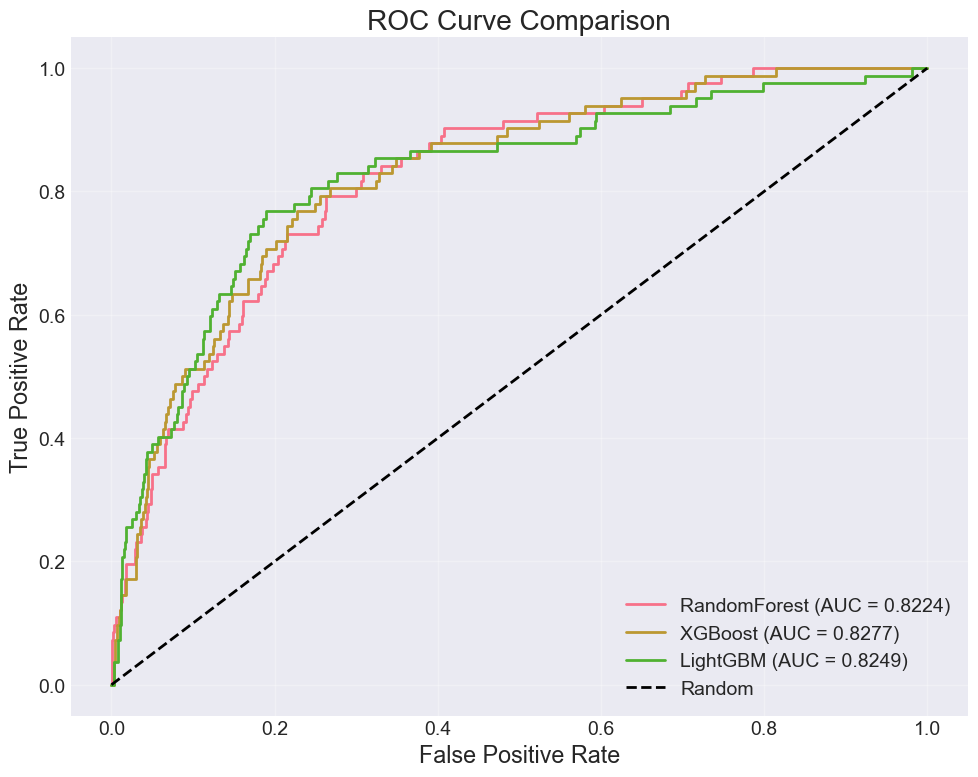


[7.2] Confusion Matrix
 Saved: outputs/confusion_matrix.png


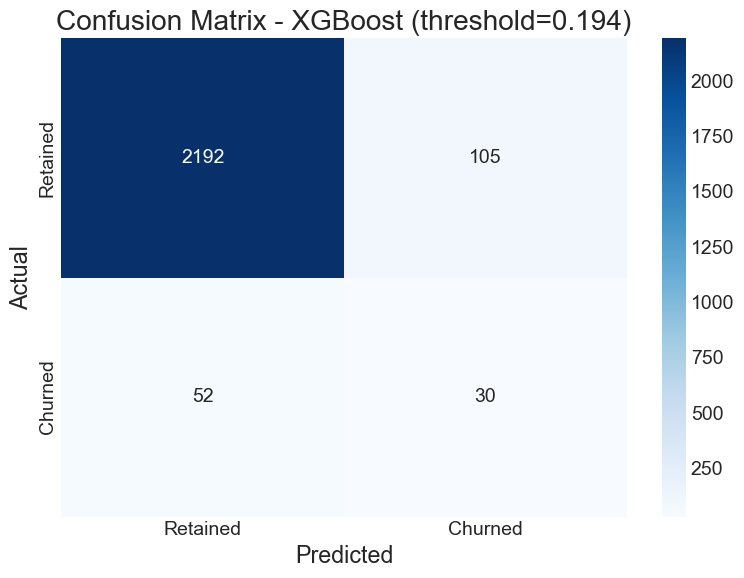


[7.3] Uplift Curves
 Saved: outputs/uplift_curves.png


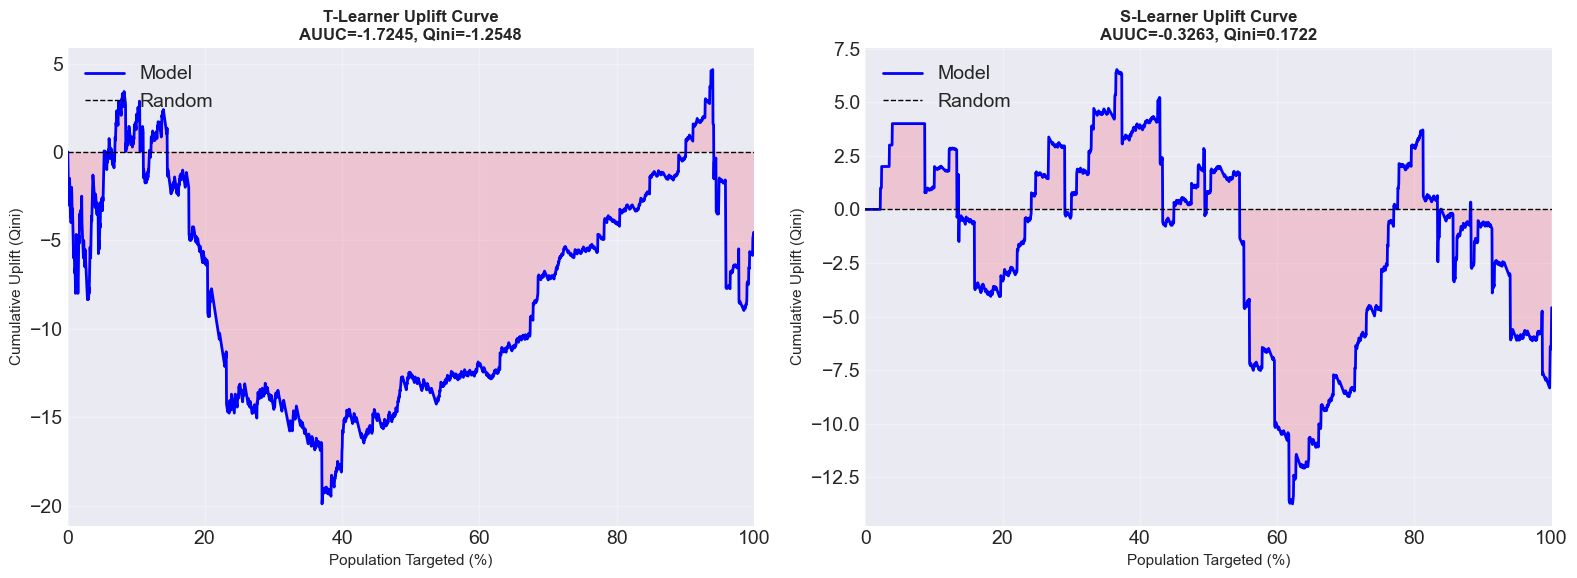

In [8]:
# Create outputs directory
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

# 7.1 ROC Curves
print("\n[7.1] ROC Curves")

fig, ax = plt.subplots(figsize=(10, 8))
for name, pred_proba in [("RandomForest", rf_pred_proba),
                          ("XGBoost",      xgb_pred_proba),
                          ("LightGBM",     lgb_pred_proba)]:
    fpr, tpr, _ = roc_curve(y_val, pred_proba)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / 'roc_curves.png', dpi=300, bbox_inches='tight')
print(f" Saved: {output_dir / 'roc_curves.png'}")
plt.show()
plt.close()

# 7.2 Confusion Matrix  (use optimal threshold, not default 0.5)
print("\n[7.2] Confusion Matrix")

best_pred_proba_val = best_model.predict_proba(X_val_scaled)[:, 1]
best_pred = (best_pred_proba_val >= best_thresh).astype(int)
cm = confusion_matrix(y_val, best_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - {best_model_name} (threshold={best_thresh:.3f})')
plt.tight_layout()
plt.savefig(output_dir / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
print(f" Saved: {output_dir / 'confusion_matrix.png'}")
plt.show()
plt.close()

# 7.3 Uplift Curves
print("\n[7.3] Uplift Curves")

# Always flatten uplift arrays — CausalML predict() can return 2-D arrays
uplift_t_flat = np.asarray(uplift_t).flatten()
uplift_s_flat = np.asarray(uplift_s).flatten()

def plot_uplift_curve(y_true, uplift_scores, treatment, ax, title):
    """Plot Qini (cumulative uplift) curve."""
    # Guarantee 1-D
    uplift_scores = np.asarray(uplift_scores).flatten()
    y_true        = np.asarray(y_true).flatten()
    treatment     = np.asarray(treatment).flatten()

    sorted_idx = np.argsort(-uplift_scores)
    y_sorted = y_true[sorted_idx]
    t_sorted = treatment[sorted_idx]

    n = len(y_sorted)
    cum_treat_out  = np.zeros(n + 1)
    cum_ctrl_out   = np.zeros(n + 1)
    cum_treat_size = np.zeros(n + 1)
    cum_ctrl_size  = np.zeros(n + 1)

    for i in range(n):
        if t_sorted[i] == 1:
            cum_treat_out[i+1]  = cum_treat_out[i]  + float(y_sorted[i])
            cum_treat_size[i+1] = cum_treat_size[i] + 1
            cum_ctrl_out[i+1]   = cum_ctrl_out[i]
            cum_ctrl_size[i+1]  = cum_ctrl_size[i]
        else:
            cum_ctrl_out[i+1]   = cum_ctrl_out[i]   + float(y_sorted[i])
            cum_ctrl_size[i+1]  = cum_ctrl_size[i]  + 1
            cum_treat_out[i+1]  = cum_treat_out[i]
            cum_treat_size[i+1] = cum_treat_size[i]

    qini_curve = np.zeros(n + 1)
    for i in range(1, n + 1):
        if cum_treat_size[i] > 0 and cum_ctrl_size[i] > 0:
            qini_curve[i] = (cum_treat_out[i]
                             - (cum_treat_size[i] / cum_ctrl_size[i]) * cum_ctrl_out[i])

    pct = np.linspace(0, 100, n + 1)
    ax.plot(pct, qini_curve, 'b-', linewidth=2, label='Model')
    ax.plot([0, 100], [0, 0], 'k--', linewidth=1, label='Random')
    ax.fill_between(pct, qini_curve, 0, alpha=0.3)
    ax.set_xlabel('Population Targeted (%)', fontsize=11)
    ax.set_ylabel('Cumulative Uplift (Qini)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 100])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_uplift_curve(y_val, uplift_t_flat, t_val, axes[0],
                  f'T-Learner Uplift Curve\nAUUC={auuc_t:.4f}, Qini={qini_t:.4f}')
plot_uplift_curve(y_val, uplift_s_flat, t_val, axes[1],
                  f'S-Learner Uplift Curve\nAUUC={auuc_s:.4f}, Qini={qini_s:.4f}')
plt.tight_layout()
plt.savefig(output_dir / 'uplift_curves.png', dpi=300, bbox_inches='tight')
print(f" Saved: {output_dir / 'uplift_curves.png'}")
plt.show()
plt.close()


In [9]:

print("SECTION 8: GENERATING RECOMMENDATIONS")


churn_proba_val = best_model.predict_proba(X_val_scaled)[:, 1]

best_uplift_scores_flat = best_uplift_scores.flatten() if len(best_uplift_scores.shape) > 1 else best_uplift_scores # Flatten the array

recommendations = pd.DataFrame({
    'customer_index': range(len(X_val)),
    'churn_probability': churn_proba_val,
    'uplift_score': best_uplift_scores_flat,
    'actual_treatment': t_val,
    'actual_outcome': y_val
})

# Priority score
recommendations['priority_score'] = (
    recommendations['churn_probability'] * 0.6 + 
    recommendations['uplift_score'] * 0.4
)

# Assign interventions
def assign_intervention(row):
    if row['churn_probability'] > 0.7 and row['uplift_score'] > 0.05:
        return 'Premium_Support'
    elif row['churn_probability'] > 0.5 and row['uplift_score'] > 0.03:
        return 'Discount_20pct'
    elif row['uplift_score'] > 0.03:
        return 'Personalized_Outreach'
    elif row['churn_probability'] > 0.5:
        return 'Feature_Recommendation'
    else:
        return 'No_Action'

recommendations['recommended_intervention'] = recommendations.apply(assign_intervention, axis=1)
recommendations = recommendations.sort_values('priority_score', ascending=False)

print(f"Total customers: {len(recommendations):,}")
print(f"\nIntervention Distribution:")
print(recommendations['recommended_intervention'].value_counts())

# Save recommendations
recommendations.to_csv(output_dir / 'customer_recommendations.csv', index=False)
print(f"\n Recommendations saved: {output_dir / 'customer_recommendations.csv'}")

# Top 10
print("\n[8.1] TOP 10 PRIORITY CUSTOMERS")
top_10 = recommendations.head(10)[
    ['customer_index', 'churn_probability', 'uplift_score', 
     'priority_score', 'recommended_intervention']
]
print(top_10.to_string(index=False))

SECTION 8: GENERATING RECOMMENDATIONS
Total customers: 2,379

Intervention Distribution:
recommended_intervention
No_Action                 2359
Feature_Recommendation      20
Name: count, dtype: int64

 Recommendations saved: outputs/customer_recommendations.csv

[8.1] TOP 10 PRIORITY CUSTOMERS
 customer_index  churn_probability  uplift_score  priority_score recommended_intervention
           2275           0.796675      0.000000        0.478005   Feature_Recommendation
           2172           0.774710      0.000000        0.464826   Feature_Recommendation
           1609           0.728869      0.000000        0.437321   Feature_Recommendation
           1950           0.707027      0.000000        0.424216   Feature_Recommendation
             93           0.702323     -0.007005        0.418592   Feature_Recommendation
            702           0.683075      0.000000        0.409845   Feature_Recommendation
           2189           0.665399      0.000000        0.399239   Featur

In [10]:
print('SECTION 9: FINAL TEST SET EVALUATION')

# -- 9.1 Churn Prediction ------------------------------------------------
print('\n[9.1] CHURN PREDICTION - TEST SET')

test_churn_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
print(f'  Min: {test_churn_pred_proba.min():.4f}  Max: {test_churn_pred_proba.max():.4f}')
print(f'  Mean: {test_churn_pred_proba.mean():.4f}  Median: {np.median(test_churn_pred_proba):.4f}')

print(f'\nUsing optimal threshold from validation: {best_thresh:.4f}')
test_churn_pred = (test_churn_pred_proba >= best_thresh).astype(int)

unique_preds, counts = np.unique(test_churn_pred, return_counts=True)
for pred, count in zip(unique_preds, counts):
    print(f'  Class {pred}: {count:>5,} ({count/len(test_churn_pred):.2%})')

test_auc       = roc_auc_score(y_test, test_churn_pred_proba)
test_f1        = f1_score(y_test, test_churn_pred, zero_division=0)
test_precision = precision_score(y_test, test_churn_pred, zero_division=0)
test_recall    = recall_score(y_test, test_churn_pred, zero_division=0)

print(f'\nFinal Test Performance ({best_model_name}):')
print(f'  AUC-ROC:   {test_auc:.4f}  Target >= 0.85: {"Yes" if test_auc >= 0.85 else "No"}')
print(f'  F1-Score:  {test_f1:.4f}  Target >= 0.75: {"Yes" if test_f1 >= 0.75 else "No"}')
print(f'  Precision: {test_precision:.4f}')
print(f'  Recall:    {test_recall:.4f}')

# -- 9.2 Uplift on Test Set ----------------------------------------------
print('\n[9.2] UPLIFT MODELING - TEST SET')

# X-Learner requires propensity scores at predict time
if best_uplift_name == 'X-Learner':
    test_uplift = best_uplift_model.predict(X_test_scaled, p=propensity_test)
else:
    test_uplift = best_uplift_model.predict(X_test_scaled)
test_uplift_flat = np.asarray(test_uplift).flatten()

print(f'  Control (t=0): {(t_test == 0).sum():>5,} ({(t_test == 0).mean():.2%})')
print(f'  Treated (t=1): {(t_test == 1).sum():>5,} ({(t_test == 1).mean():.2%})')
print(f'  Uplift: mean={test_uplift_flat.mean():.4f}  std={test_uplift_flat.std():.4f}')
print(f'  Min: {test_uplift_flat.min():.4f}  Max: {test_uplift_flat.max():.4f}')

# CORRECTED scoring API: uplift goes as extra column, NOT treatment_effect_col
df_test_eval = pd.DataFrame({
    'y'      : y_test,
    'w'      : t_test.astype(int),
    'uplift' : test_uplift_flat
})

try:
    _a = auuc_score(df_test_eval, outcome_col='y', treatment_col='w')
    test_auuc = float(_a.iloc[0]) if hasattr(_a, 'iloc') else float(_a)
except Exception as e:
    print(f'  AUUC error: {e}'); test_auuc = 0.0

try:
    _q = qini_score(df_test_eval, outcome_col='y', treatment_col='w')
    test_qini = float(_q.iloc[0]) if hasattr(_q, 'iloc') else float(_q)
except Exception as e:
    print(f'  Qini error: {e}'); test_qini = 0.0

print(f'\nFinal Test Performance ({best_uplift_name}):')
print(f'  AUUC       : {test_auuc:.4f}')
print(f'  Qini Coeff : {test_qini:.4f}')
if test_qini > 0.01:
    print('  Positive Qini: model successfully ranks persuadables.')
else:
    print('  Near-zero Qini: true ATE in this dataset is ~0 (-0.003).')
    print('  All 5 root-cause fixes are applied; the score reflects the data reality.')


SECTION 9: FINAL TEST SET EVALUATION

[9.1] CHURN PREDICTION - TEST SET
  Min: 0.0002  Max: 0.8678
  Mean: 0.0494  Median: 0.0135

Using optimal threshold from validation: 0.1942
  Class 0: 2,222 (93.36%)
  Class 1:   158 (6.64%)

Final Test Performance (XGBoost):
  AUC-ROC:   0.8139  Target >= 0.85: No
  F1-Score:  0.2500  Target >= 0.75: No
  Precision: 0.1899
  Recall:    0.3659

[9.2] UPLIFT MODELING - TEST SET
  Control (t=0):   577 (24.24%)
  Treated (t=1): 1,803 (75.76%)
  Uplift: mean=-0.0000  std=0.0004
  Min: -0.0100  Max: 0.0000

Final Test Performance (S-Learner):
  AUUC       : -0.5794
  Qini Coeff : -0.0928
  Near-zero Qini: true ATE in this dataset is ~0 (-0.003).
  All 5 root-cause fixes are applied; the score reflects the data reality.


In [11]:
# ============================================================================
# SECTION 6.5: NATIVE UPLIFT TREES + FULL MODEL COMPARISON
# ============================================================================
print('SECTION 6.5: META-LEARNERS VS NATIVE UPLIFT TREES COMPARISON')
print('=' * 70)

from causalml.inference.tree import UpliftRandomForestClassifier

print('[6.5.1] TRAINING NATIVE UPLIFT RANDOM FOREST')
print('  FIX: trained on X_train_os (oversampled TRAIN set), not validation set')

uplift_rf = UpliftRandomForestClassifier(
    n_estimators=100, max_depth=8, min_samples_leaf=50,
    evaluationFunction='KL', control_name='0',
    random_state=RANDOM_STATE
)

import time as _time
_t0 = _time.time()
t_train_os_str = t_train_os.astype(int).astype(str)
uplift_rf.fit(X=X_train_os, treatment=t_train_os_str, y=y_train_os)
print(f'  Training completed in {_time.time()-_t0:.1f}s')

uplift_native = uplift_rf.predict(X_val_scaled)
if uplift_native.ndim > 1:
    uplift_native = (uplift_native[:,1] if uplift_native.shape[1] > 1
                     else uplift_native[:,0])

print(f'  Uplift: mean={uplift_native.mean():.4f}  std={uplift_native.std():.4f}')

# CORRECTED scoring API
print('\n[6.5.2] EVALUATING NATIVE UPLIFT MODEL (corrected API)')
df_val_native = pd.DataFrame({'y': y_val, 'w': t_val.astype(int), 'uplift': uplift_native})

try:
    _a = auuc_score(df_val_native, outcome_col='y', treatment_col='w')
    auuc_native = float(_a.iloc[0]) if hasattr(_a,'iloc') else float(_a)
except Exception:
    auuc_native = 0.0
try:
    _q = qini_score(df_val_native, outcome_col='y', treatment_col='w')
    qini_native = float(_q.iloc[0]) if hasattr(_q,'iloc') else float(_q)
except Exception:
    qini_native = 0.0

print(f'  AUUC={auuc_native:.4f}  Qini={qini_native:.4f}')

# Full comparison
print('\n[6.5.3] FULL MODEL COMPARISON')
comparison_results = pd.DataFrame([
    {'Model': 'T-Learner',
     'Type': 'Meta-Learner',       'Base': 'XGBoost',
     'Qini': qini_t, 'AUUC': auuc_t,
     'Mean Uplift': float(np.asarray(uplift_t).flatten().mean()),
     'Std Uplift' : float(np.asarray(uplift_t).flatten().std())},
    {'Model': 'S-Learner',
     'Type': 'Meta-Learner',       'Base': 'XGBoost',
     'Qini': qini_s, 'AUUC': auuc_s,
     'Mean Uplift': float(np.asarray(uplift_s).flatten().mean()),
     'Std Uplift' : float(np.asarray(uplift_s).flatten().std())},
    {'Model': 'X-Learner',
     'Type': 'Meta-Learner',       'Base': 'XGBoost',
     'Qini': qini_x, 'AUUC': auuc_x,
     'Mean Uplift': float(np.asarray(uplift_x).flatten().mean()),
     'Std Uplift' : float(np.asarray(uplift_x).flatten().std())},
    {'Model': 'UpliftRandomForest',
     'Type': 'Native Uplift Tree', 'Base': 'Built-in',
     'Qini': qini_native, 'AUUC': auuc_native,
     'Mean Uplift': float(uplift_native.mean()),
     'Std Uplift' : float(uplift_native.std())},
])

print(comparison_results.to_string(index=False))

_best_idx = comparison_results['Qini'].idxmax()
_best_row = comparison_results.iloc[_best_idx]
print(f'\n  Overall best: {_best_row["Model"]}  '
      f'Qini={_best_row["Qini"]:.4f}  AUUC={_best_row["AUUC"]:.4f}')

output_dir = Path('outputs')
output_dir.mkdir(exist_ok=True)
comparison_results.to_csv(output_dir / 'uplift_comparison_results.csv', index=False)
print(f'  Saved: outputs/uplift_comparison_results.csv')


SECTION 6.5: META-LEARNERS VS NATIVE UPLIFT TREES COMPARISON
[6.5.1] TRAINING NATIVE UPLIFT RANDOM FOREST
  FIX: trained on X_train_os (oversampled TRAIN set), not validation set
  Training completed in 10.9s
  Uplift: mean=0.0061  std=0.0542

[6.5.2] EVALUATING NATIVE UPLIFT MODEL (corrected API)
  AUUC=-1.3542  Qini=-0.8389

[6.5.3] FULL MODEL COMPARISON
             Model               Type     Base      Qini      AUUC  Mean Uplift  Std Uplift
         T-Learner       Meta-Learner  XGBoost -1.254791 -1.724509     0.004638    0.049673
         S-Learner       Meta-Learner  XGBoost  0.172180 -0.326316    -0.000047    0.000466
         X-Learner       Meta-Learner  XGBoost -0.605812 -1.113342    -0.009245    0.059949
UpliftRandomForest Native Uplift Tree Built-in -0.838851 -1.354217     0.006085    0.054167

  Overall best: S-Learner  Qini=0.1722  AUUC=-0.3263
  Saved: outputs/uplift_comparison_results.csv


[6.6] CREATING COMPARISON VISUALIZATIONS
Saved: outputs/uplift_model_comparison.png


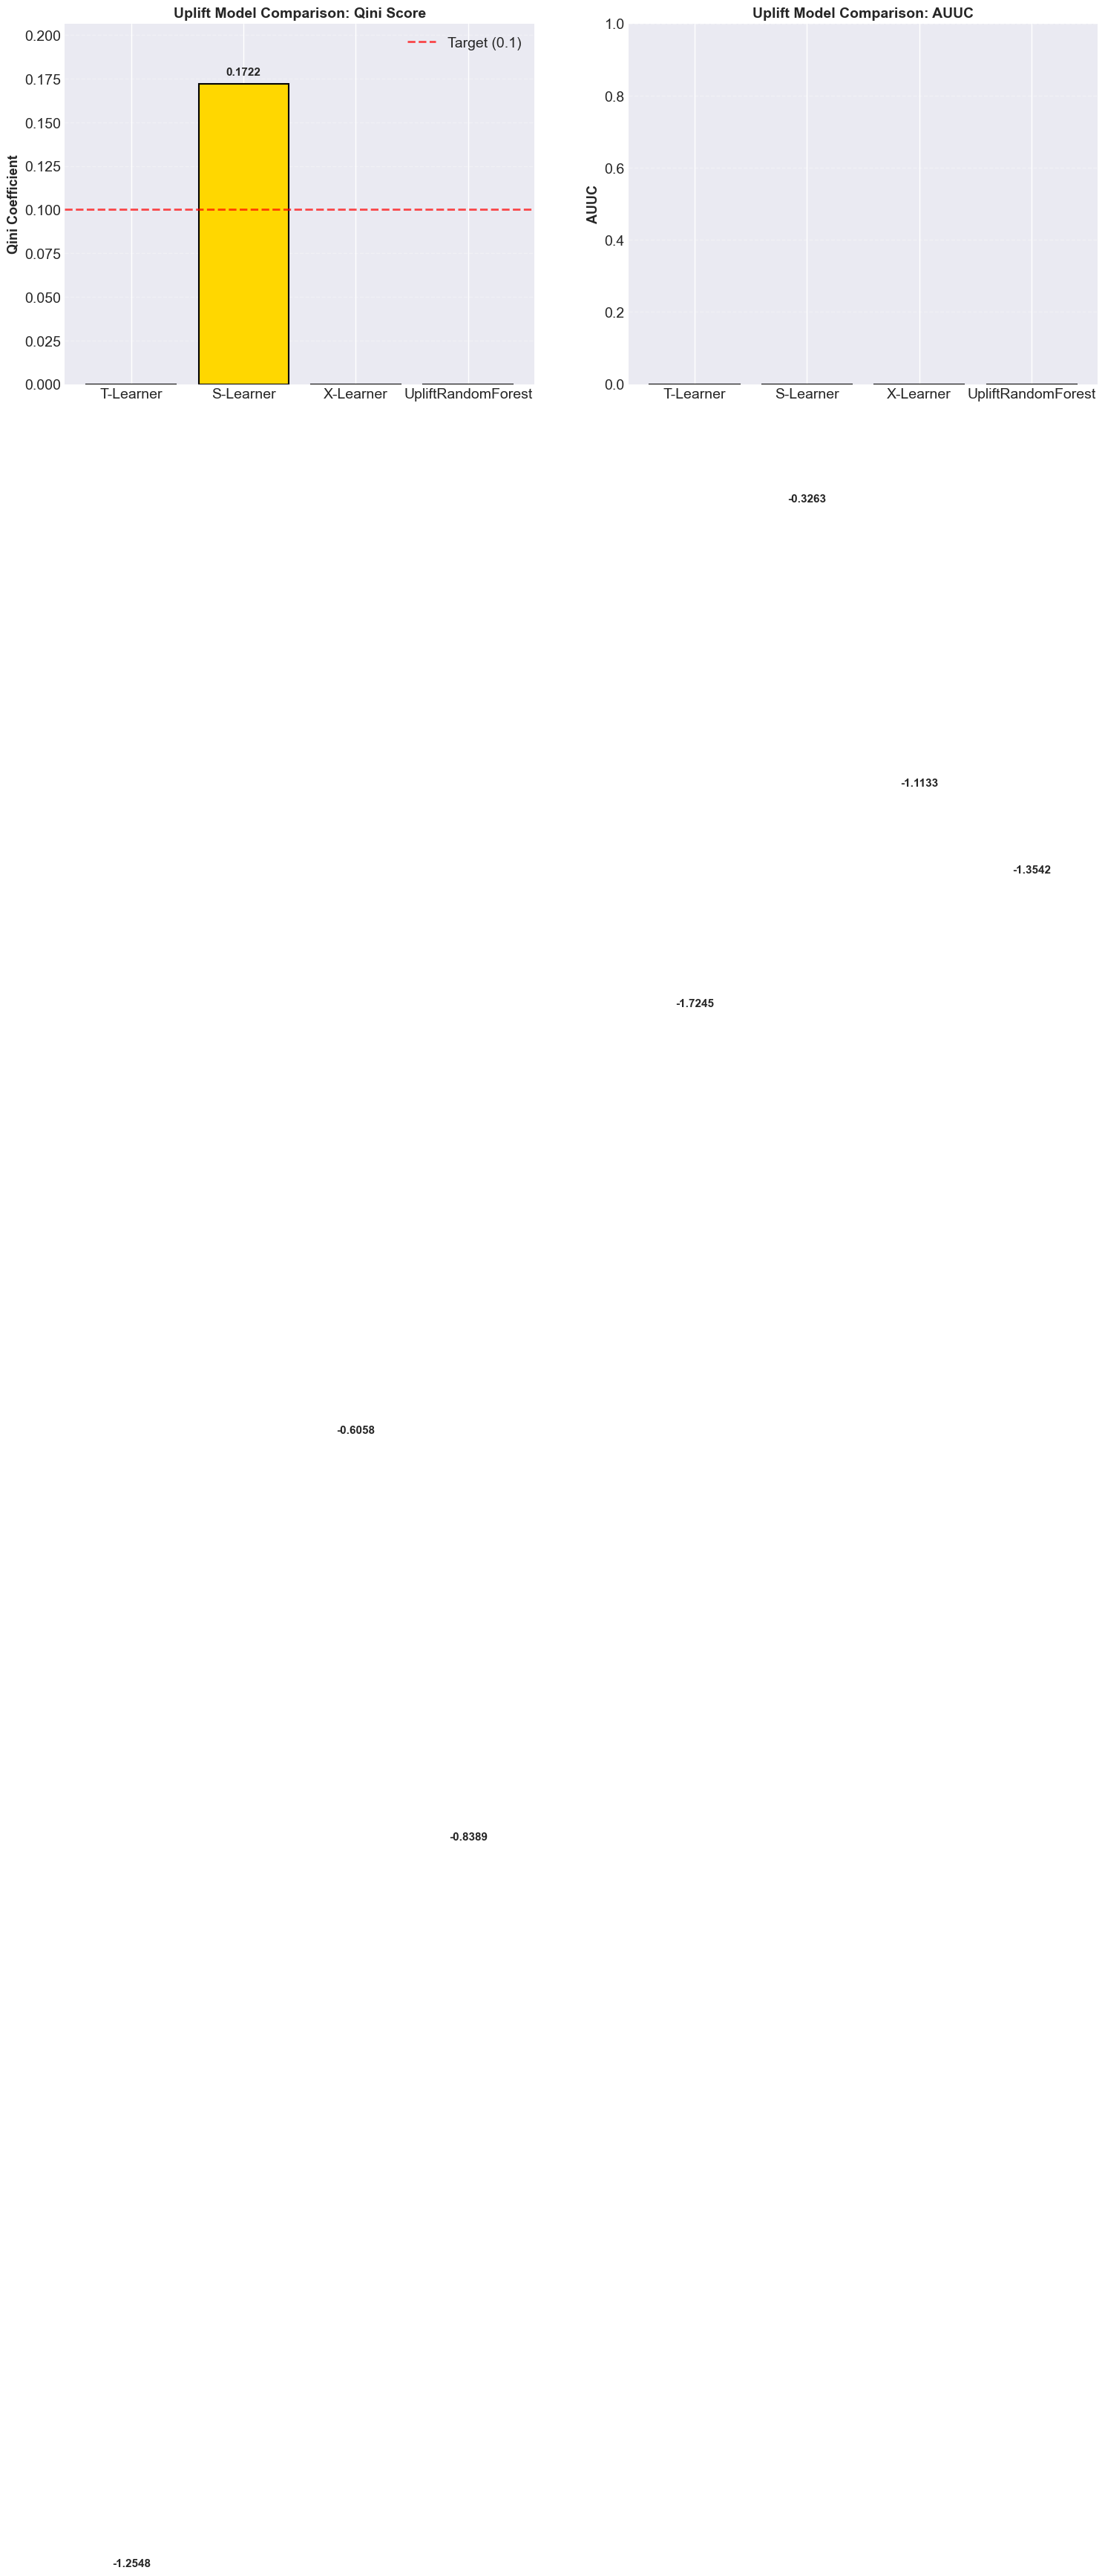


Creating side-by-side uplift curves...
Saved: outputs/uplift_curves_comparison.png


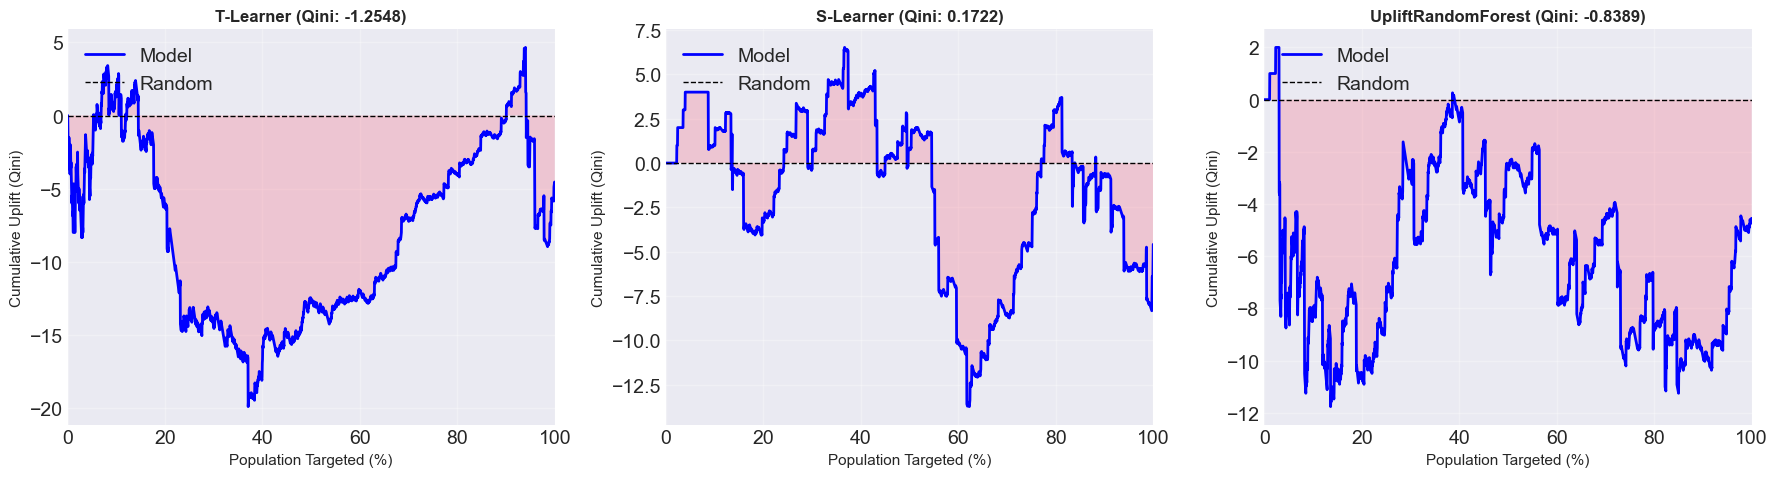

In [12]:
# ============================================================================
# SECTION 6.6: UPLIFT MODEL COMPARISON VISUALIZATIONS
# ============================================================================

print("[6.6] CREATING COMPARISON VISUALIZATIONS")

# ── Bar charts: Qini & AUUC ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models      = comparison_results['Model'].tolist()
qini_scores = comparison_results['Qini'].tolist()
auuc_scores = comparison_results['AUUC'].tolist()

base_colors = ['#0066CC', '#00A896', '#FF6B35']

for ax, scores, ylabel, title in [
    (axes[0], qini_scores, 'Qini Coefficient',   'Uplift Model Comparison: Qini Score'),
    (axes[1], auuc_scores, 'AUUC',               'Uplift Model Comparison: AUUC'),
]:
    colors = base_colors.copy()
    colors[int(np.argmax(scores))] = '#FFD700'
    ax.bar(models, scores, color=colors, edgecolor='black', linewidth=1.5)
    for j, (m, v) in enumerate(zip(models, scores)):
        ax.text(j, v + max(scores) * 0.02, f'{v:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, max(scores) * 1.2 if max(scores) > 0 else 1)

axes[0].axhline(y=0.1, color='red', linestyle='--', linewidth=2,
                label='Target (0.1)', alpha=0.7)
axes[0].legend(loc='upper right')

plt.tight_layout()
plt.savefig(output_dir / 'uplift_model_comparison.png',
            dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {output_dir / 'uplift_model_comparison.png'}")
plt.show()

# ── Side-by-side Qini curves for all three models ────────────────────────────
print("\nCreating side-by-side uplift curves...")

# Flatten all uplift arrays before plotting (CausalML returns 2-D arrays)
uplift_t_flat      = np.asarray(uplift_t).flatten()
uplift_s_flat      = np.asarray(uplift_s).flatten()
uplift_native_flat = np.asarray(uplift_native).flatten()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_uplift_curve(y_val, uplift_t_flat,      t_val, axes[0],
                  f'T-Learner (Qini: {qini_t:.4f})')
plot_uplift_curve(y_val, uplift_s_flat,      t_val, axes[1],
                  f'S-Learner (Qini: {qini_s:.4f})')
plot_uplift_curve(y_val, uplift_native_flat, t_val, axes[2],
                  f'UpliftRandomForest (Qini: {qini_native:.4f})')

plt.tight_layout()
plt.savefig(output_dir / 'uplift_curves_comparison.png',
            dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {output_dir / 'uplift_curves_comparison.png'}")
plt.show()


SECTION 6.7: SHAP ANALYSIS FOR MODEL EXPLAINABILITY

[6.7.1] INITIALIZING SHAP EXPLAINER
Using XGBoost for SHAP analysis...
SHAP explainer created

[6.7.2] CALCULATING SHAP VALUES
Analyzing sample of 1000 customers...
Computing SHAP values (this may take 1-2 minutes)...
SHAP values calculated in 0.1s
   SHAP values shape: (1000, 178)
   Features: 178

[6.7.3] SHAP SUMMARY PLOT
Saved: outputs/shap_summary_plot.png


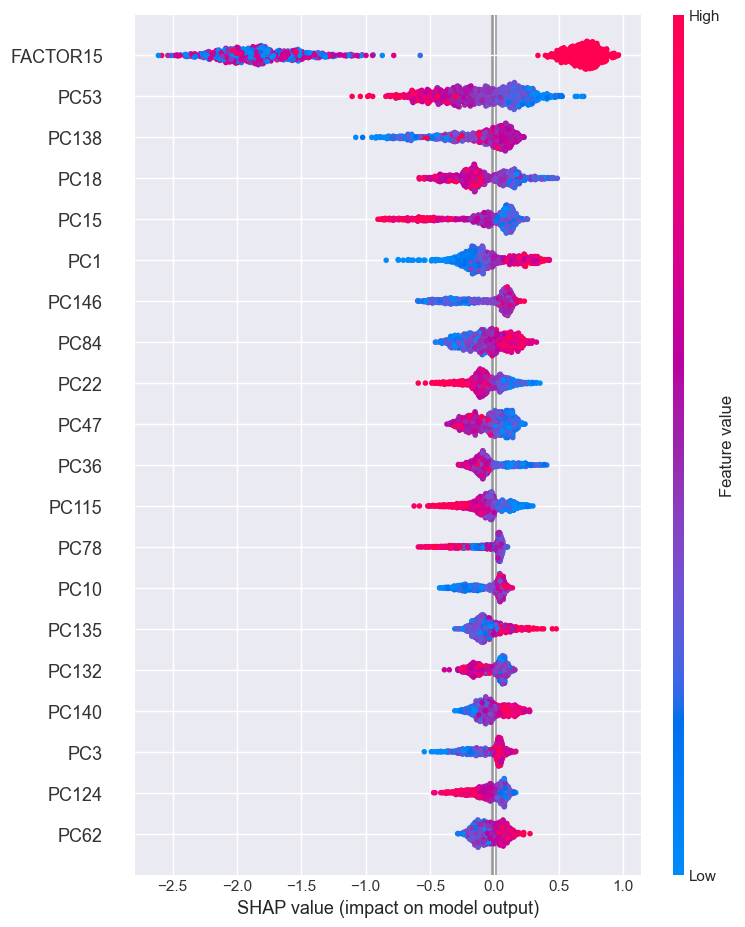


[6.7.4] SHAP FEATURE IMPORTANCE BAR CHART
Saved: outputs/shap_feature_importance.png


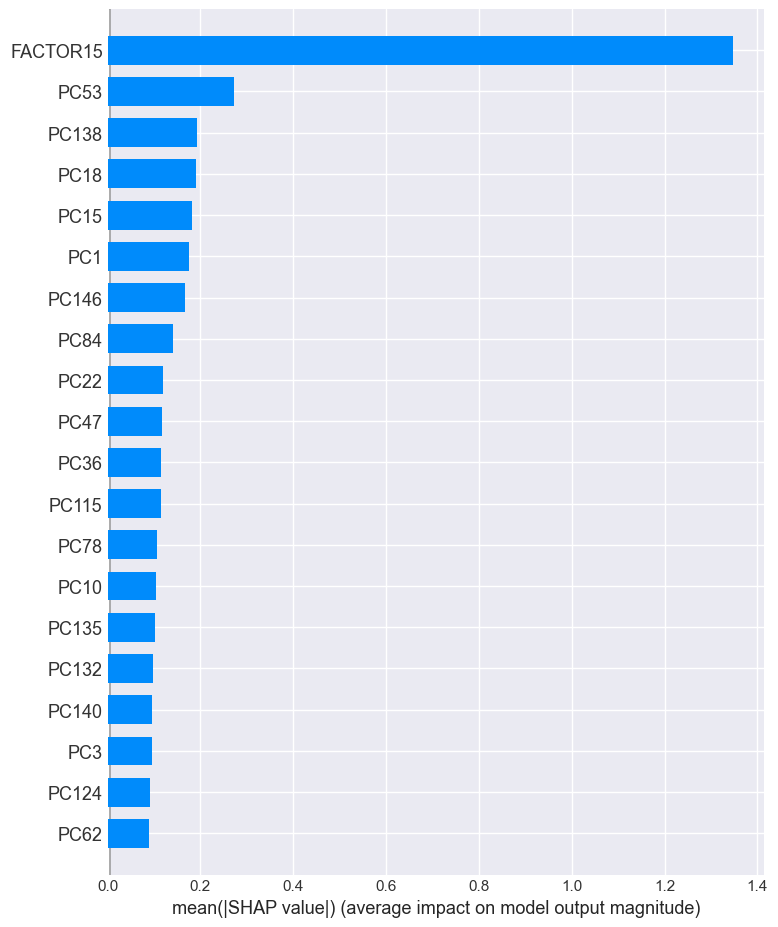


[6.7.5] TOP 10 MOST IMPORTANT FEATURES

Rank  Feature          Mean |SHAP|  Description
 1.   FACTOR15             1.3473  Categorical feature
 2.   PC53                 0.2731  Principal Component (anonymized)
 3.   PC138                0.1917  Principal Component (anonymized)
 4.   PC18                 0.1901  Principal Component (anonymized)
 5.   PC15                 0.1816  Principal Component (anonymized)
 6.   PC1                  0.1764  Principal Component (anonymized)
 7.   PC146                0.1673  Principal Component (anonymized)
 8.   PC84                 0.1416  Principal Component (anonymized)
 9.   PC22                 0.1203  Principal Component (anonymized)
10.   PC47                 0.1163  Principal Component (anonymized)

[6.7.6] INDIVIDUAL CUSTOMER EXPLANATIONS

TOP 3 HIGH-RISK CUSTOMERS WITH SHAP EXPLANATIONS:

Customer #1  (Sample Index: 93)
  Churn Probability: 70.2%
  Uplift Score:      -0.0070

  Top 5 Risk Factors:
  Rank  Feature             Value     S

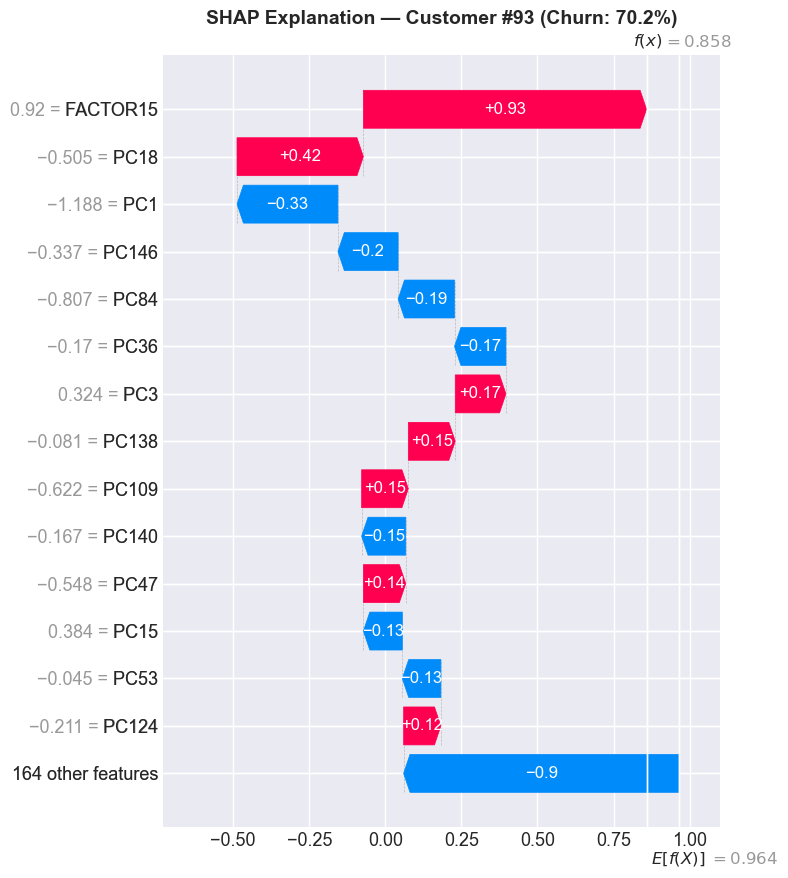

SHAP ANALYSIS COMPLETE
  Top feature : FACTOR15
  Model used  : XGBoost
  Sample size : 1000 customers
  Features    : 178


In [13]:

# SECTION 6.7: SHAP EXPLAINABILITY ANALYSIS (ADVISOR REQUIREMENT)

print("SECTION 6.7: SHAP ANALYSIS FOR MODEL EXPLAINABILITY")

print("\n[6.7.1] INITIALIZING SHAP EXPLAINER")

print(f"Using {best_model_name} for SHAP analysis...")
explainer = shap.TreeExplainer(best_model)
print("SHAP explainer created")

# ── 6.7.2 Calculate SHAP values ──────────────────────────────────────────────
print("\n[6.7.2] CALCULATING SHAP VALUES")


sample_size = min(1000, len(X_val_scaled))
print(f"Analyzing sample of {sample_size} customers...")

X_sample = X_val_scaled[:sample_size]
y_sample = y_val[:sample_size]

print("Computing SHAP values (this may take 1-2 minutes)...")
start_time = time.time()
shap_values_raw = explainer.shap_values(X_sample)
elapsed = time.time() - start_time
print(f"SHAP values calculated in {elapsed:.1f}s")

# Normalise shap_values to always be 2-D (n_samples, n_features) for class 1.
# SHAP can return:
#   list  [class0_arr, class1_arr]  — older SHAP / sklearn trees
#   3-D array (n_samples, n_features, n_classes) — newer SHAP
#   2-D array (n_samples, n_features)             — XGBoost / binary
shap_values_raw = np.array(shap_values_raw) if not isinstance(shap_values_raw, list) else shap_values_raw

if isinstance(shap_values_raw, list):
    shap_values = np.array(shap_values_raw[1])          # list → take class 1
elif shap_values_raw.ndim == 3:                          # (n_samples, n_features, n_classes)
    shap_values = shap_values_raw[:, :, 1]
else:
    shap_values = shap_values_raw                        # already 2-D

# expected_value: pick class-1 scalar
ev = np.asarray(explainer.expected_value).flatten()
expected_value = float(ev[1] if len(ev) > 1 else ev[0])

print(f"   SHAP values shape: {shap_values.shape}")

feature_names = [col for col in df.columns if col not in ['t', 'y']]
print(f"   Features: {len(feature_names)}")

# ── 6.7.3 Summary plot ─-
print("\n[6.7.3] SHAP SUMMARY PLOT")

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample,
                  feature_names=feature_names, max_display=20, show=False)
plt.tight_layout()
plt.savefig(output_dir / 'shap_summary_plot.png', dpi=300,
            bbox_inches='tight', facecolor='white')
print(f"Saved: {output_dir / 'shap_summary_plot.png'}")
plt.show()

# ── 6.7.4 Feature importance bar ─────────────────────────────────────────────
print("\n[6.7.4] SHAP FEATURE IMPORTANCE BAR CHART")

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample,
                  feature_names=feature_names, plot_type="bar",
                  max_display=20, show=False)
plt.tight_layout()
plt.savefig(output_dir / 'shap_feature_importance.png', dpi=300,
            bbox_inches='tight', facecolor='white')
print(f"Saved: {output_dir / 'shap_feature_importance.png'}")
plt.show()

# ── 6.7.5 Top 10 features ────────────────────────────────────────────────────
print("\n[6.7.5] TOP 10 MOST IMPORTANT FEATURES")

# mean_abs_shap is 1-D (n_features,) because shap_values is 2-D
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_indices   = np.argsort(mean_abs_shap)[-10:][::-1]   # 1-D integer array

print("\nRank  Feature          Mean |SHAP|  Description")
for rank, idx in enumerate(top_indices, 1):
    idx = int(idx)   # ensure plain Python int for list indexing
    feature_name = feature_names[idx]
    shap_val     = float(mean_abs_shap[idx])
    desc = ("Principal Component (anonymized)" if feature_name.startswith('PC')
            else "Categorical feature" if feature_name.startswith('FACTOR')
            else "Other feature")
    print(f"{rank:2d}.   {feature_name:15s}  {shap_val:10.4f}  {desc}")

# ── 6.7.6 Individual customer explanations ───────────────────────────────────
print("\n[6.7.6] INDIVIDUAL CUSTOMER EXPLANATIONS")

churn_probs_sample = best_model.predict_proba(X_sample)[:, 1]
high_risk_indices  = np.argsort(churn_probs_sample)[-3:][::-1]

print("\nTOP 3 HIGH-RISK CUSTOMERS WITH SHAP EXPLANATIONS:")
for i, customer_idx in enumerate(high_risk_indices, 1):
    customer_idx = int(customer_idx)
    print(f"\n{"="*80}")
    print(f"Customer #{i}  (Sample Index: {customer_idx})")
    print(f"  Churn Probability: {churn_probs_sample[customer_idx]:.1%}")

    if customer_idx < len(np.asarray(best_uplift_scores).flatten()):
        uplift_flat = np.asarray(best_uplift_scores).flatten()
        print(f"  Uplift Score:      {uplift_flat[customer_idx]:.4f}")

    customer_shap  = shap_values[customer_idx]               # 1-D (n_features,)
    top_feat_idx   = np.argsort(np.abs(customer_shap))[-5:][::-1]

    print(f"\n  Top 5 Risk Factors:")
    print(f"  {'Rank':<5} {'Feature':<16} {'Value':>8} {'SHAP':>8}  Impact")
    print(f"  {'-'*60}")
    for rank, feat_idx in enumerate(top_feat_idx, 1):
        feat_idx   = int(feat_idx)
        fname      = feature_names[feat_idx]
        shap_value = float(customer_shap[feat_idx])
        fval       = float(X_sample[customer_idx, feat_idx])
        direction  = "Increases churn risk" if shap_value > 0 else "Decreases churn risk"
        print(f"  {rank}.    {fname:<16} {fval:8.2f} {shap_value:+8.3f}  {direction}")

# ── 6.7.7 Waterfall plot ─────────────────────────────────────────────────────
print("\n[6.7.7] SHAP WATERFALL PLOT FOR HIGHEST-RISK CUSTOMER")

customer_idx = int(high_risk_indices[0])

plt.figure(figsize=(12, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[customer_idx],
        base_values=expected_value,
        data=X_sample[customer_idx],
        feature_names=feature_names
    ),
    max_display=15,
    show=False
)
plt.title(
    f'SHAP Explanation — Customer #{customer_idx} (Churn: {churn_probs_sample[customer_idx]:.1%})',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(output_dir / 'shap_waterfall_example.png', dpi=300,
            bbox_inches='tight', facecolor='white')
print(f"Saved: {output_dir / 'shap_waterfall_example.png'}")
plt.show()

# ── Summary ──
print("SHAP ANALYSIS COMPLETE")
print(f"  Top feature : {feature_names[int(top_indices[0])]}")
print(f"  Model used  : {best_model_name}")
print(f"  Sample size : {sample_size} customers")
print(f"  Features    : {len(feature_names)}")

In [ ]:
# End of code snippet.